In [1]:
!pip install wordfreq -q

In [2]:
import re
import numpy as np
import pandas as pd
import wordfreq
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)
print('Uploaded file:', filename)
print('Total rows:', len(df))
df.head()

Saving AoA_refined_dataset_v3_freq5.xlsx to AoA_refined_dataset_v3_freq5 (7).xlsx
Uploaded file: AoA_refined_dataset_v3_freq5 (7).xlsx
Total rows: 5889


,Word,Alternative.spelling,Freq_pm,Dom_PoS_SUBTLEX,Nletters,Nphon,Nsyll,Lemma_highest_PoS,AoA_Kup,Perc_known,AoA_Kup_lem,Perc_known_lem,AoA_Bird_lem,AoA_Bristol_lem,AoA_Cort_lem,AoA_Schock,Perc_known_final,AoA_final,Age_Group,AoA_source
0,a,a,20415.274510,Article,1,1,1,a,2.893384,1.0,2.893384,1.0,3.156247,NaN,NaN,NaN,1.0,2.893384,below_6,AoA_Kup
1,abandon,abandon,8.098039,Verb,7,7,3,abandon,8.320000,1.0,8.320000,1.0,NaN,NaN,NaN,NaN,1.0,8.320000,age_8_plus,AoA_Kup
2,abandoned,abandoned,13.294118,Verb,9,8,3,abandon,NaN,NaN,8.320000,1.0,NaN,NaN,NaN,NaN,1.0,8.320000,age_8_plus,AoA_Kup_lem
3,abducted,abducted,5.000000,Verb,8,8,3,abduct,NaN,NaN,11.260000,1.0,NaN,NaN,NaN,9.48848,1.0,11.260000,age_8_plus,AoA_Kup_lem
4,abilities,abilities,6.117647,Noun,9,8,4,ability,NaN,NaN,8.840000,1.0,NaN,8.97764,NaN,NaN,1.0,8.840000,age_8_plus,AoA_Kup_lem


In [23]:
PARAMETERS = {
    'seed': 42,
    'word_col': 'Word',
    'target_col': 'AoA_Kup',
    'perc_known_col': 'Perc_known',
    'threshold_age': 7.0,
    'perc_known_min': 0.6,
    'test_size': 0.2,
    'val_size_within_tv': 0.2,
    'alphas': [0.001, 0.01, 0.1, 1.0],
    'lr': 0.001,
    'epochs': 2000,
    'default_threshold': 0.5,
    'threshold_start': 0.10,
    'threshold_end': 0.90,
    'threshold_step': 0.02,
}

FEATURES = ['n_letters', 'n_syll_est', 'zipf_score']

HEDGE_BANDS = [
    (0.25, 'Most children aged {age} would likely know this word'),
    (0.40, 'Children aged {age} would likely know this word'),
    (0.60, 'This word may or may not be familiar to children aged {age}'),
    (0.75, 'This word may be unfamiliar to children aged {age}'),
    (1.00, 'This word is likely unfamiliar to children aged {age}')
]


In [24]:
def clean_word(word):
    return re.sub(r'[^a-z]', '', str(word).lower().strip())


def to_binary(v, threshold_age):
    return 1 if v >= threshold_age else 0


def estimate_syllables(word):
    w = clean_word(word)

    if not w:
        return 1

    vowels = 'aeiouy'
    count = 0
    prev_is_vowel = False

    for ch in w:
        is_vowel = ch in vowels
        if is_vowel and not prev_is_vowel:
            count += 1
        prev_is_vowel = is_vowel

    if w.endswith('e') and count > 1:
        count -= 1

    return max(count, 1)


def build_features(word):
    w = str(word).lower().strip()

    n_letters = len(clean_word(w))
    n_syll_est = estimate_syllables(w)
    zipf = wordfreq.zipf_frequency(w, 'en')

    return {
        'n_letters': float(n_letters),
        'n_syll_est': float(n_syll_est),
        'zipf_score': float(zipf)
    }


def normalize_word_form(word):
    w = clean_word(word)

    if not w:
        return w

    if len(w) > 4 and w.endswith('ies'):
        return w[:-3] + 'y'

    if len(w) > 4 and w.endswith('es') and w.endswith(('ses', 'xes', 'zes', 'ches', 'shes')):
        return w[:-2]

    if len(w) > 3 and w.endswith('s') and not w.endswith('ss') and not w.endswith('sis'):
        return w[:-1]

    return w


def hedge_message(p, threshold_age):
    age = int(threshold_age)
    for upper, message in HEDGE_BANDS:
        if p < upper:
            return message.format(age=age)
    return HEDGE_BANDS[-1][1].format(age=age)


In [25]:
class StandardScaler:
    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.scale_[self.scale_ == 0] = 1.0
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) / self.scale_


class BinaryLogisticRegression:
    def __init__(self, alpha=0.01, lr=0.01, epochs=500):
        self.alpha = alpha
        self.lr = lr
        self.epochs = epochs

    @staticmethod
    def _sigmoid(z):
        return np.where(
            z >= 0,
            1.0 / (1.0 + np.exp(-z)),
            np.exp(z) / (1.0 + np.exp(z))
        )

    def fit(self, X, y, print_every=50):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)

        n, p = X.shape
        self.w_ = np.zeros(p, dtype=float)
        self.b_ = 0.0
        self.loss_history_ = []

        for epoch in range(1, self.epochs + 1):
            z = X @ self.w_ + self.b_
            p_hat = np.clip(self._sigmoid(z), 1e-12, 1 - 1e-12)

            ce = -(y * np.log(p_hat) + (1 - y) * np.log(1 - p_hat))
            loss = ce.mean() + self.alpha * (self.w_ ** 2).sum()
            self.loss_history_.append(loss)

            residual = (p_hat - y) / n
            grad_w = X.T @ residual + 2 * self.alpha * self.w_
            grad_b = residual.sum()

            self.w_ -= self.lr * grad_w
            self.b_ -= self.lr * grad_b

            if epoch == 1 or epoch % print_every == 0 or epoch == self.epochs:
                print(f'Epoch {epoch:>4}/{self.epochs}  loss={loss:.4f}')

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        p1 = self._sigmoid(X @ self.w_ + self.b_)
        return np.stack([1 - p1, p1], axis=1)

def predict_word(word, clf, scaler, threshold_age, threshold):
    raw_word = str(word).lower().strip()
    norm_word = normalize_word_form(raw_word)

    raw_features = build_features(raw_word)
    x_raw = np.array([[raw_features[f] for f in FEATURES]], dtype=float)
    p_raw = clf.predict_proba(scaler.transform(x_raw))[0, 1]

    if norm_word and norm_word != raw_word:
        norm_features = build_features(norm_word)
        x_norm = np.array([[norm_features[f] for f in FEATURES]], dtype=float)
        p_norm = clf.predict_proba(scaler.transform(x_norm))[0, 1]
        p_final = 0.5 * p_raw + 0.5 * p_norm
    else:
        p_final = p_raw

    label = 'difficult' if p_final >= threshold else 'easy'
    message = hedge_message(p_final, threshold_age)

    print(f'{word:<20} p={p_final:.3f}   {label:<12} {message}')


Final dataset size: 4253
label
0    2084
1    2169
Name: count, dtype: int64


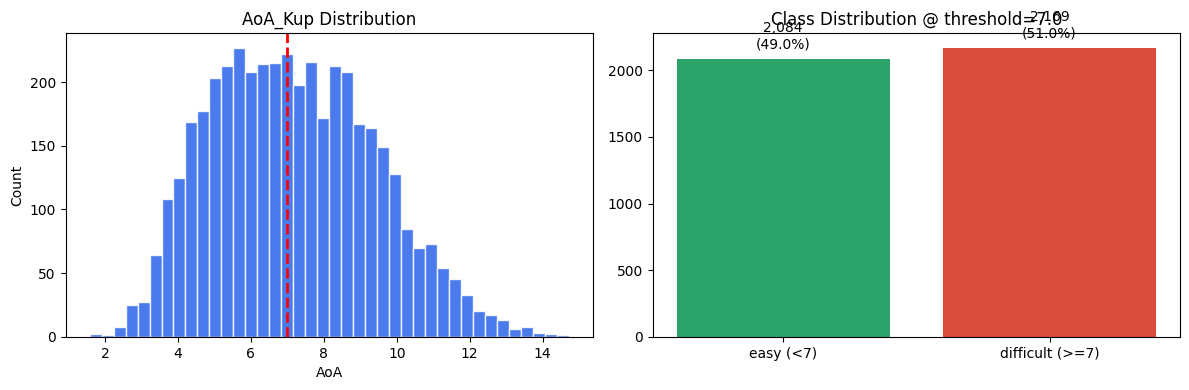

In [26]:
df = df[df[PARAMETERS['target_col']].notna()].copy()
df = df[df[PARAMETERS['perc_known_col']] >= PARAMETERS['perc_known_min']].copy()
df[PARAMETERS['word_col']] = df[PARAMETERS['word_col']].astype(str)

feature_df = df[PARAMETERS['word_col']].apply(build_features).apply(pd.Series)
df = pd.concat([df, feature_df], axis=1)

df = df.dropna(subset=FEATURES + [PARAMETERS['target_col']]).reset_index(drop=True)

df['label'] = df[PARAMETERS['target_col']].apply(
    lambda value: to_binary(value, PARAMETERS['threshold_age'])
)

LABELS = [
    f"easy (<{PARAMETERS['threshold_age']:g})",
    f"difficult (>={PARAMETERS['threshold_age']:g})"
]

print('Final dataset size:', len(df))
print(df['label'].value_counts().sort_index())

counts = df['label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    df[PARAMETERS['target_col']],
    bins=40,
    color='#2A63E8',
    alpha=0.85,
    edgecolor='white'
)
axes[0].axvline(
    PARAMETERS['threshold_age'],
    color='red',
    linestyle='--',
    linewidth=2
)
axes[0].set_title(f"{PARAMETERS['target_col']} Distribution")
axes[0].set_xlabel('AoA')
axes[0].set_ylabel('Count')

axes[1].bar(
    [LABELS[i] for i in counts.index],
    counts.values,
    color=['#2BA36B', '#D94B3B']
)
axes[1].set_title(f"Class Distribution @ threshold={PARAMETERS['threshold_age']}")

for i, value in enumerate(counts.values):
    axes[1].text(
        i,
        value + 80,
        f'{value:,}\n({value / len(df) * 100:.1f}%)',
        ha='center'
    )

plt.tight_layout()
plt.show()


In [27]:
X = df[FEATURES].values.astype(float)
y = df['label'].values.astype(int)

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y,
    test_size=PARAMETERS['test_size'],
    random_state=PARAMETERS['seed'],
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=PARAMETERS['val_size_within_tv'],
    random_state=PARAMETERS['seed'],
    stratify=y_tv
)

print('Train:', len(X_train), '| Val:', len(X_val), '| Test:', len(X_test))

Train: 2721 | Val: 681 | Test: 851


In [28]:
scaler_train = StandardScaler().fit(X_train)
Xtr_s = scaler_train.transform(X_train)
Xval_s = scaler_train.transform(X_val)

best_alpha = None
best_threshold = PARAMETERS['default_threshold']
best_mcc = -1
best_model = None

print('Joint alpha + threshold sweep on validation:\n')

for alpha in PARAMETERS['alphas']:
    model = BinaryLogisticRegression(
        alpha=alpha,
        lr=PARAMETERS['lr'],
        epochs=PARAMETERS['epochs']
    )
    model.fit(Xtr_s, y_train, print_every=10000)

    val_probs = model.predict_proba(Xval_s)[:, 1]

    alpha_best_thr = PARAMETERS['default_threshold']
    alpha_best_mcc = -1

    for thr in np.arange(
        PARAMETERS['threshold_start'],
        PARAMETERS['threshold_end'] + 1e-9,
        PARAMETERS['threshold_step']
    ):
        val_pred = (val_probs >= thr).astype(int)
        score = matthews_corrcoef(y_val, val_pred)

        if score > alpha_best_mcc:
            alpha_best_mcc = score
            alpha_best_thr = float(round(thr, 4))

    print(f'  alpha={alpha:<8} best_thr={alpha_best_thr:.2f}  val_mcc={alpha_best_mcc:.3f}')

    if alpha_best_mcc > best_mcc:
        best_mcc = alpha_best_mcc
        best_alpha = alpha
        best_threshold = alpha_best_thr
        best_model = model

print(f'\nBest alpha: {best_alpha}')
print(f'Best threshold: {best_threshold}')
print(f'Best val MCC: {best_mcc:.3f}')

Joint alpha + threshold sweep on validation:

Epoch    1/2000  loss=0.6931
Epoch 2000/2000  loss=0.6013
  alpha=0.001    best_thr=0.50  val_mcc=0.410
Epoch    1/2000  loss=0.6931
Epoch 2000/2000  loss=0.6031
  alpha=0.01     best_thr=0.50  val_mcc=0.410
Epoch    1/2000  loss=0.6931
Epoch 2000/2000  loss=0.6181
  alpha=0.1      best_thr=0.50  val_mcc=0.413
Epoch    1/2000  loss=0.6931
Epoch 2000/2000  loss=0.6650
  alpha=1.0      best_thr=0.50  val_mcc=0.415

Best alpha: 1.0
Best threshold: 0.5
Best val MCC: 0.415



Retraining on train+val (alpha=1.0) ...
Epoch    1/2000  loss=0.6931
Epoch  100/2000  loss=0.6804
Epoch  200/2000  loss=0.6732
Epoch  300/2000  loss=0.6692
Epoch  400/2000  loss=0.6669
Epoch  500/2000  loss=0.6657
Epoch  600/2000  loss=0.6649
Epoch  700/2000  loss=0.6645
Epoch  800/2000  loss=0.6643
Epoch  900/2000  loss=0.6642
Epoch 1000/2000  loss=0.6641
Epoch 1100/2000  loss=0.6641
Epoch 1200/2000  loss=0.6640
Epoch 1300/2000  loss=0.6640
Epoch 1400/2000  loss=0.6640
Epoch 1500/2000  loss=0.6640
Epoch 1600/2000  loss=0.6640
Epoch 1700/2000  loss=0.6640
Epoch 1800/2000  loss=0.6640
Epoch 1900/2000  loss=0.6640
Epoch 2000/2000  loss=0.6640


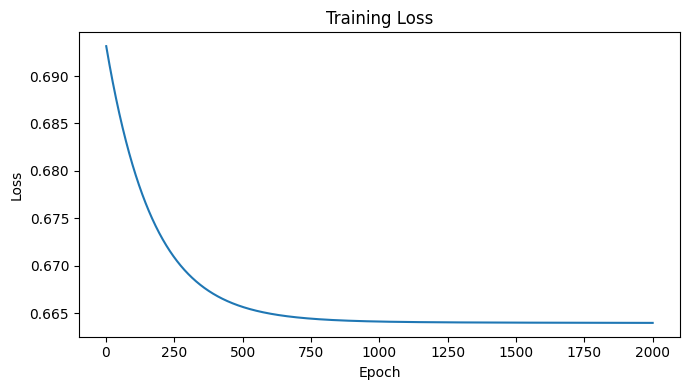

In [29]:
scaler = StandardScaler().fit(X_tv)
Xtv_s = scaler.transform(X_tv)
Xte_s = scaler.transform(X_test)

clf = BinaryLogisticRegression(
    alpha=best_alpha,
    lr=PARAMETERS['lr'],
    epochs=PARAMETERS['epochs']
)

print(f'\nRetraining on train+val (alpha={best_alpha}) ...')
clf.fit(Xtv_s, y_tv, print_every=100)

plt.figure(figsize=(7, 4))
plt.plot(range(1, clf.epochs + 1), clf.loss_history_)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

In [30]:
test_probs = clf.predict_proba(Xte_s)[:, 1]
y_pred_default = (test_probs >= PARAMETERS['default_threshold']).astype(int)
y_pred_tuned = (test_probs >= best_threshold).astype(int)

print(f'\n--- Threshold = {PARAMETERS["default_threshold"]} (default) ---')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_default):.3f}')
print(f'MCC       : {matthews_corrcoef(y_test, y_pred_default):.3f}')
print(f'F1        : {f1_score(y_test, y_pred_default):.3f}')
print(f'Precision : {precision_score(y_test, y_pred_default, zero_division=0):.3f}')
print(f'Recall    : {recall_score(y_test, y_pred_default, zero_division=0):.3f}')

print(f'\n--- Threshold = {best_threshold:.2f} (tuned) ---')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_tuned):.3f}')
print(f'MCC       : {matthews_corrcoef(y_test, y_pred_tuned):.3f}')
print(f'F1        : {f1_score(y_test, y_pred_tuned):.3f}')
print(f'Precision : {precision_score(y_test, y_pred_tuned, zero_division=0):.3f}')
print(f'Recall    : {recall_score(y_test, y_pred_tuned, zero_division=0):.3f}')



--- Threshold = 0.5 (default) ---
Accuracy  : 0.692
MCC       : 0.384
F1        : 0.695
Precision : 0.702
Recall    : 0.689

--- Threshold = 0.50 (tuned) ---
Accuracy  : 0.692
MCC       : 0.384
F1        : 0.695
Precision : 0.702
Recall    : 0.689


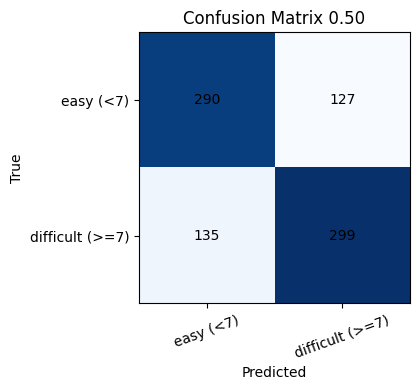

In [31]:
cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title(f'Confusion Matrix {best_threshold:.2f}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks([0, 1], LABELS, rotation=20)
plt.yticks([0, 1], LABELS)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.tight_layout()
plt.show()


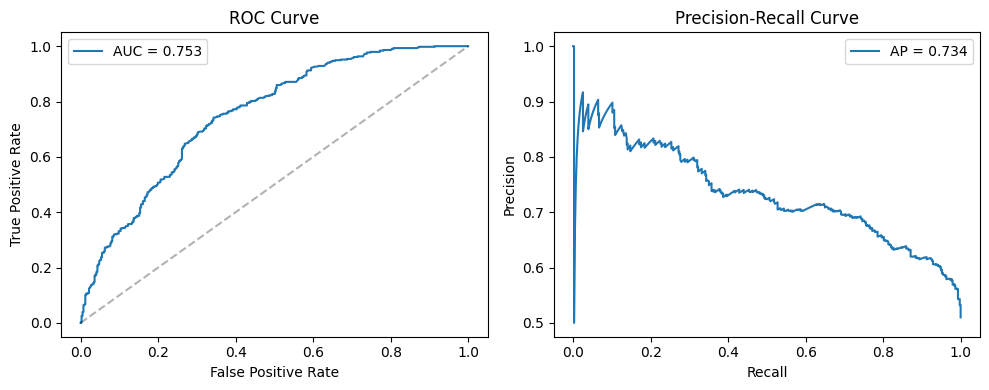

In [32]:
fpr, tpr, _ = roc_curve(y_test, test_probs)
precision, recall, _ = precision_recall_curve(y_test, test_probs)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, test_probs):.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].plot(recall, precision, label=f'AP = {average_precision_score(y_test, test_probs):.3f}')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()